In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from utils.parse_coscheduling_runs import CoSchedulingRunsParser

In [7]:
parser = CoSchedulingRunsParser()
data_isolated = parser.parse_isolated("../sample_data/experiments_coscheduling_isolated/20260521_194041/data")
data_coscheduled = parser.parse_coscheduled("../sample_data/experiments_coscheduling_app_coscheduled/20260521_200212/data")

In [8]:
# Aggregate data_isolated by App and Num Nodes
# Group by App and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_isolated_agg = data_isolated.groupby(['App', 'Num Nodes']).agg({
    'App Time Average': ['mean', 'median', 'std'],
    'MPI Time Average': ['mean', 'median', 'std'],
    'Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_isolated_agg.columns = ['App', 'Num Nodes', 
                             'App Time Average Mean', 'App Time Average Median', 'App Time Average Std',
                             'MPI Time Average Mean', 'MPI Time Average Median', 'MPI Time Average Std',
                             'Total Messages Sent Mean', 'Total Messages Sent Median', 'Total Messages Sent Std']

data_isolated_agg

,App,Num Nodes,App Time Average Mean,App Time Average Median,App Time Average Std,MPI Time Average Mean,MPI Time Average Median,MPI Time Average Std,Total Messages Sent Mean,Total Messages Sent Median,Total Messages Sent Std
0,beatnik,1,577.802632,578.315789,5.406344,130.155263,129.720175,2.452984,375894.0,375894.0,0.00000
1,fiesta,1,329.061404,329.000000,0.907036,28.118377,28.453947,1.298929,67200.0,67200.0,0.00000
2,lammps,1,422.631579,422.631579,1.012895,14.949605,14.954123,0.600363,44688.0,44688.0,0.00000
3,minife,1,408.052632,407.859649,5.150570,14.275439,14.512281,5.675681,637048.0,637048.0,0.00000
4,minivite,1,560.508772,510.701754,103.467116,88.706272,38.340614,105.443841,749746.5,749754.0,3058.84537
5,tricount,1,466.421053,466.175439,2.650923,111.773684,111.797368,1.869574,243320.0,243320.0,0.00000


In [9]:
# Aggregate data_coscheduled by App A, App B, and Num Nodes
# Group by App A, App B, and Num Nodes, then calculate mean, median, std for each metric across Run Iterations
data_coscheduled_agg = data_coscheduled.groupby(['App A', 'App B', 'Num Nodes']).agg({
    'App A Time Average': ['mean', 'median', 'std'],
    'App B Time Average': ['mean', 'median', 'std'],
    'App A MPI Time Average': ['mean', 'median', 'std'],
    'App B MPI Time Average': ['mean', 'median', 'std'],
    'App A Total Messages Sent': ['mean', 'median', 'std'],
    'App B Total Messages Sent': ['mean', 'median', 'std']
}).reset_index()

# Flatten column names
data_coscheduled_agg.columns = ['App A', 'App B', 'Num Nodes',
                                'App A Time Average Mean', 'App A Time Average Median', 'App A Time Average Std',
                                'App B Time Average Mean', 'App B Time Average Median', 'App B Time Average Std',
                                'App A MPI Time Average Mean', 'App A MPI Time Average Median', 'App A MPI Time Average Std',
                                'App B MPI Time Average Mean', 'App B MPI Time Average Median', 'App B MPI Time Average Std',
                                'App A Total Messages Sent Mean', 'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
                                'App B Total Messages Sent Mean', 'App B Total Messages Sent Median', 'App B Total Messages Sent Std']

data_coscheduled_agg

,App A,App B,Num Nodes,App A Time Average Mean,App A Time Average Median,App A Time Average Std,App B Time Average Mean,App B Time Average Median,App B Time Average Std,App A MPI Time Average Mean,...,App A MPI Time Average Std,App B MPI Time Average Mean,App B MPI Time Average Median,App B MPI Time Average Std,App A Total Messages Sent Mean,App A Total Messages Sent Median,App A Total Messages Sent Std,App B Total Messages Sent Mean,App B Total Messages Sent Median,App B Total Messages Sent Std
0,beatnik,fiesta,1,739.087719,736.877193,15.662858,582.535088,582.614035,0.211741,190.517544,...,1.560987,74.935044,75.289912,3.054968,375894.00,375894.0,0.000000,67200.00,67200.0,0.000000
1,beatnik,lammps,1,738.333333,731.508772,15.144020,515.105263,515.298246,1.139316,189.164035,...,1.629833,8.184386,8.225439,0.578944,375894.00,375894.0,0.000000,44688.00,44688.0,0.000000
2,beatnik,minivite,1,745.978070,748.622807,15.358640,614.035088,614.035088,2.666051,187.289912,...,3.173018,33.442632,33.300088,2.110325,375894.00,375894.0,0.000000,750130.50,750603.0,2792.915144
3,beatnik,tricount,1,734.293860,729.877193,11.803271,551.263158,551.017544,4.031068,189.360526,...,1.748866,97.942105,97.424561,1.711925,375894.00,375894.0,0.000000,243320.00,243320.0,0.000000
4,lammps,fiesta,1,517.403509,517.157895,4.431992,580.938596,580.929825,2.005967,9.085921,...,0.813992,75.970526,77.398772,7.244443,44688.00,44688.0,0.000000,67200.00,67200.0,0.000000
5,minivite,fiesta,1,623.771930,620.105263,10.160243,581.921053,581.745614,0.457151,39.126491,...,8.320938,79.521053,77.660526,6.392799,750915.00,752293.5,2846.480985,67200.00,67200.0,0.000000
6,minivite,lammps,1,619.614035,617.754386,6.078587,521.368421,521.368421,4.301741,39.328158,...,6.779503,8.832325,8.817193,0.488888,751523.25,752383.5,1816.065596,44688.00,44688.0,0.000000
7,tricount,fiesta,1,555.421053,552.877193,9.018818,581.535088,581.877193,1.128867,98.172368,...,0.787762,81.664825,81.520000,5.203159,243320.00,243320.0,0.000000,67200.00,67200.0,0.000000
8,tricount,lammps,1,549.403509,549.157895,1.906397,522.491228,524.105263,8.852588,97.772368,...,1.060477,8.697632,8.564825,0.781267,243320.00,243320.0,0.000000,44688.00,44688.0,0.000000
9,tricount,minivite,1,550.087719,550.526316,1.790391,621.912281,621.473684,4.945709,98.434211,...,0.443802,39.909956,40.503421,6.518335,243320.00,243320.0,0.000000,749775.75,749748.0,2930.907752


In [10]:
data_isolated_agg.columns

Index(['App', 'Num Nodes', 'App Time Average Mean', 'App Time Average Median',
       'App Time Average Std', 'MPI Time Average Mean',
       'MPI Time Average Median', 'MPI Time Average Std',
       'Total Messages Sent Mean', 'Total Messages Sent Median',
       'Total Messages Sent Std'],
      dtype='str')

In [11]:
data_coscheduled_agg.columns

Index(['App A', 'App B', 'Num Nodes', 'App A Time Average Mean',
       'App A Time Average Median', 'App A Time Average Std',
       'App B Time Average Mean', 'App B Time Average Median',
       'App B Time Average Std', 'App A MPI Time Average Mean',
       'App A MPI Time Average Median', 'App A MPI Time Average Std',
       'App B MPI Time Average Mean', 'App B MPI Time Average Median',
       'App B MPI Time Average Std', 'App A Total Messages Sent Mean',
       'App A Total Messages Sent Median', 'App A Total Messages Sent Std',
       'App B Total Messages Sent Mean', 'App B Total Messages Sent Median',
       'App B Total Messages Sent Std'],
      dtype='str')

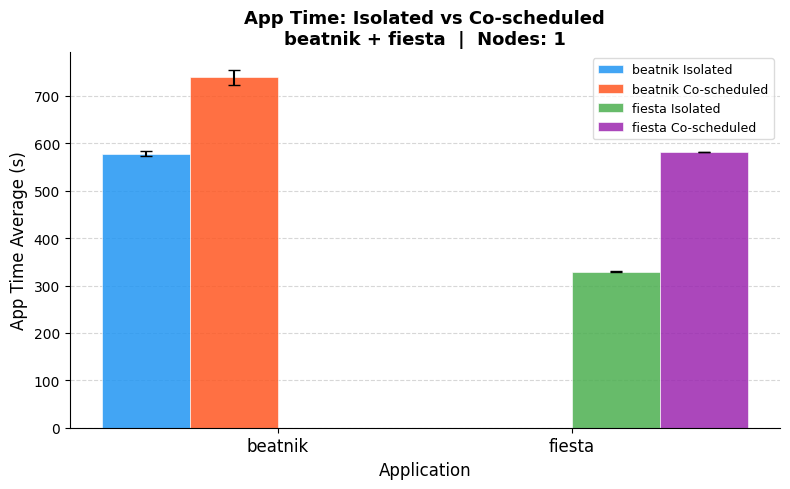

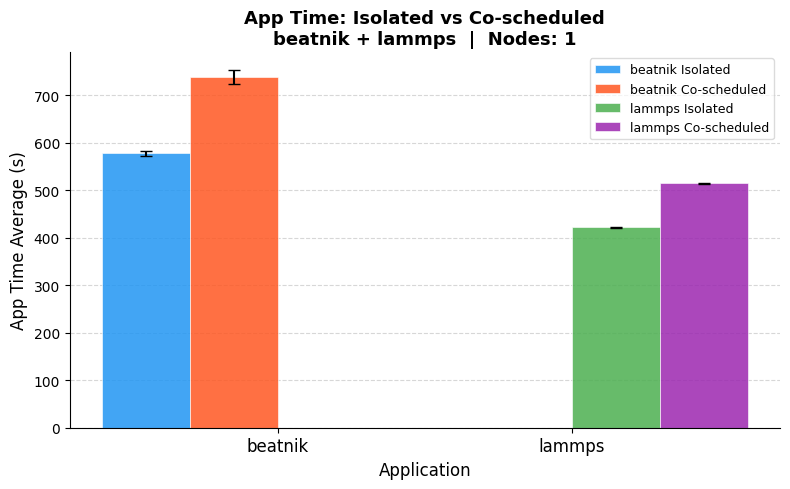

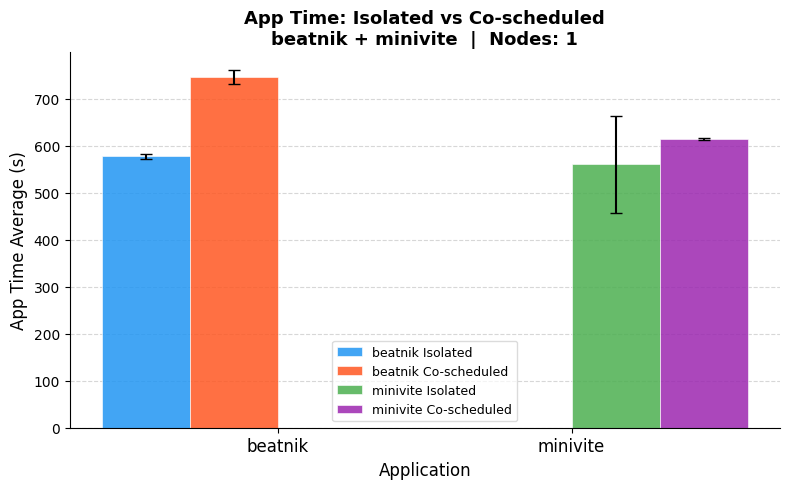

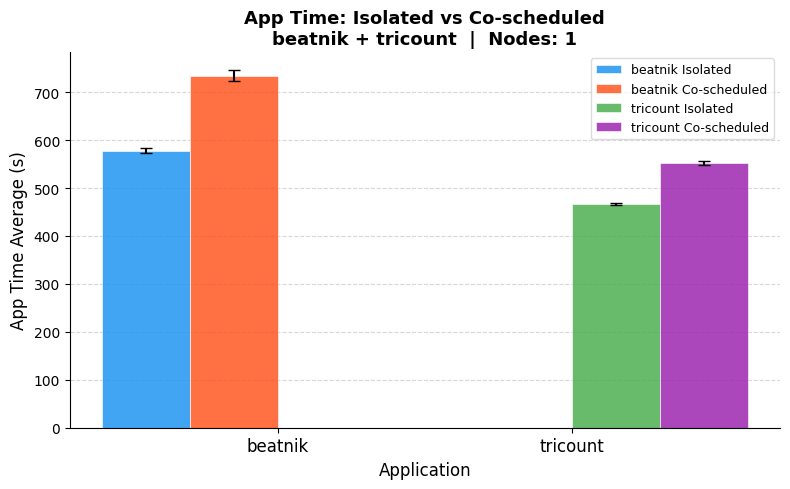

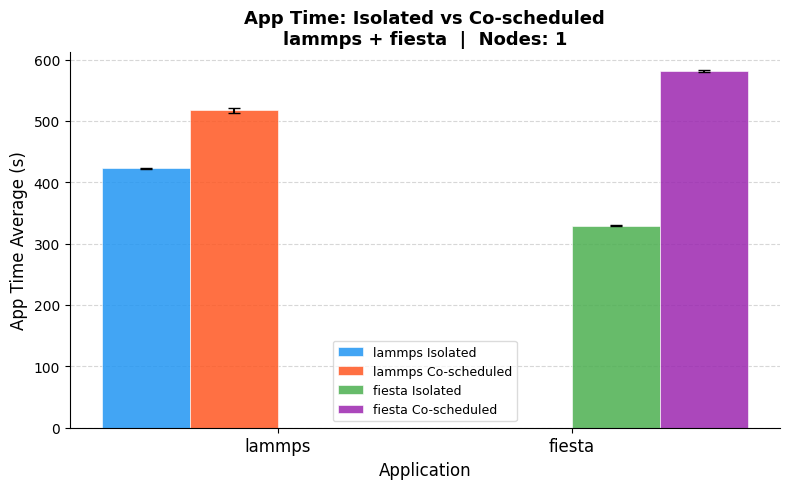

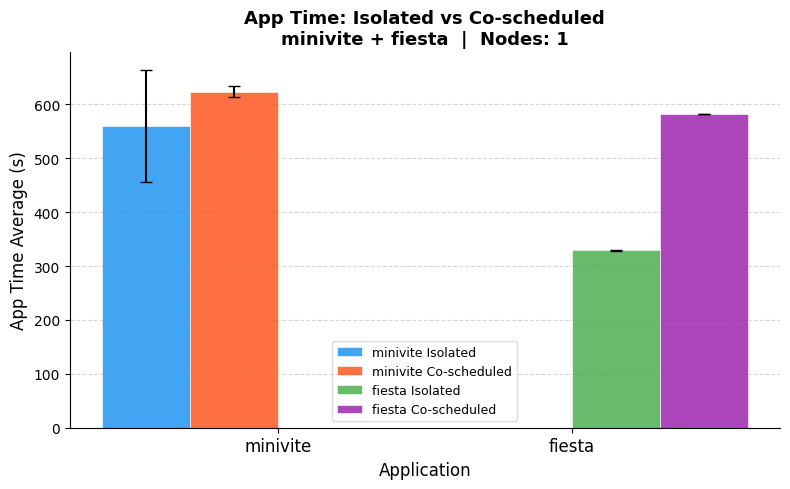

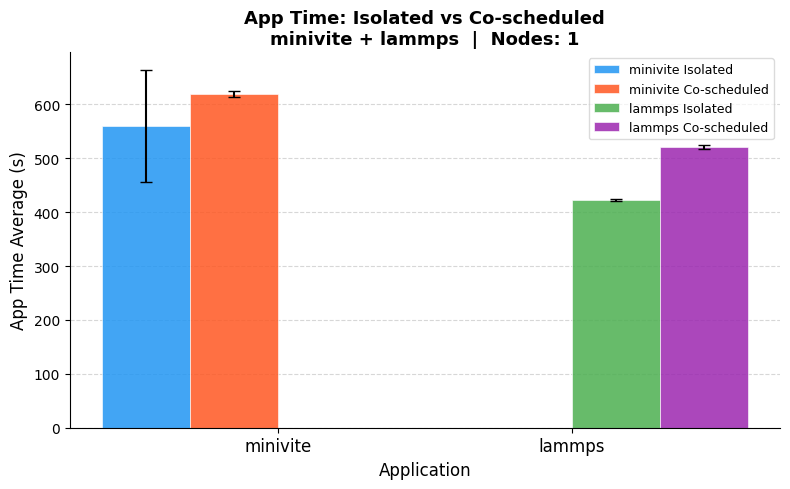

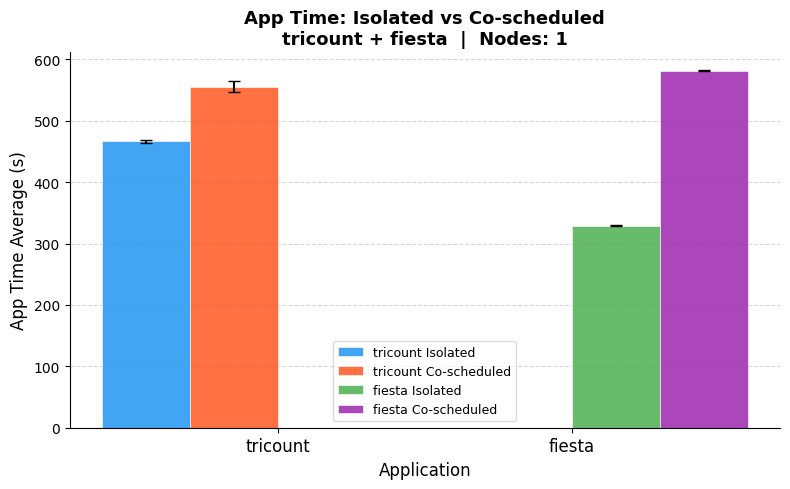

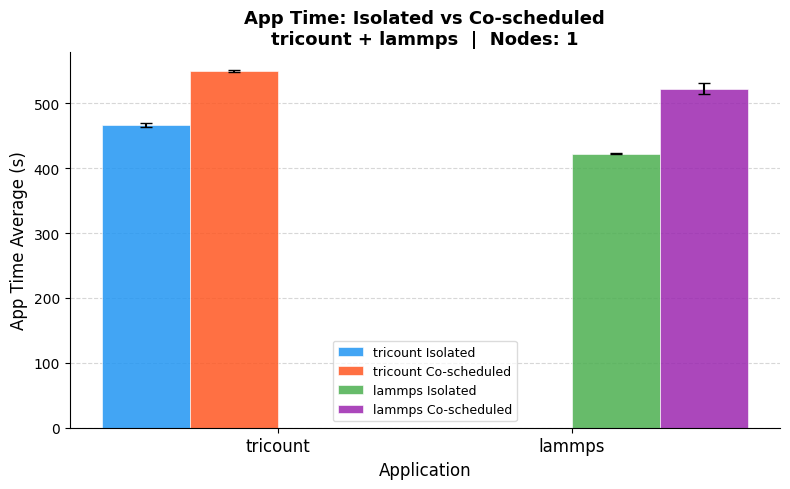

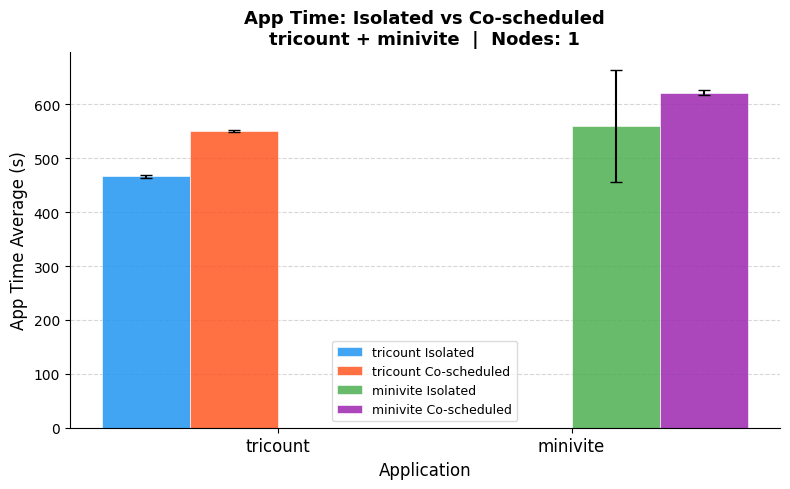

In [ ]:
def plot_coscheduled_comparisons(data_isolated_agg, data_coscheduled_agg, metric="app"):

    if metric == "app":
        iso_mean_col   = 'App Time Average Mean'
        iso_std_col    = 'App Time Average Std'
        cos_a_mean_col = 'App A Time Average Mean'
        cos_a_std_col  = 'App A Time Average Std'
        cos_b_mean_col = 'App B Time Average Mean'
        cos_b_std_col  = 'App B Time Average Std'
        y_label        = 'App Time Average (s)'
        title_metric   = 'App Time'
    elif metric == "mpi":
        iso_mean_col   = 'MPI Time Average Mean'
        iso_std_col    = 'MPI Time Average Std'
        cos_a_mean_col = 'App A MPI Time Average Mean'
        cos_a_std_col  = 'App A MPI Time Average Std'
        cos_b_mean_col = 'App B MPI Time Average Mean'
        cos_b_std_col  = 'App B MPI Time Average Std'
        y_label        = 'MPI Time Average (s)'
        title_metric   = 'MPI Time'
    else:
        raise ValueError(f"Unknown metric '{metric}'. Choose 'app' or 'mpi'.")

    for _, cosched_row in data_coscheduled_agg.iterrows():
        app_a = cosched_row['App A']
        app_b = cosched_row['App B']
        num_nodes = cosched_row['Num Nodes']

        iso_a = data_isolated_agg[
            (data_isolated_agg['App'] == app_a) &
            (data_isolated_agg['Num Nodes'] == num_nodes)
        ]
        iso_b = data_isolated_agg[
            (data_isolated_agg['App'] == app_b) &
            (data_isolated_agg['Num Nodes'] == num_nodes)
        ]

        iso_a_mean = iso_a[iso_mean_col].values[0] if not iso_a.empty else 0
        iso_a_std  = iso_a[iso_std_col].values[0]  if not iso_a.empty else 0
        iso_b_mean = iso_b[iso_mean_col].values[0] if not iso_b.empty else 0
        iso_b_std  = iso_b[iso_std_col].values[0]  if not iso_b.empty else 0

        cos_a_mean = cosched_row[cos_a_mean_col]
        cos_a_std  = cosched_row[cos_a_std_col]
        cos_b_mean = cosched_row[cos_b_mean_col]
        cos_b_std  = cosched_row[cos_b_std_col]

        fig, ax = plt.subplots(figsize=(8, 5))

        bar_width = 0.18
        x = np.array([0.0, 0.6])
        offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

        bars_data = [
            (x[0] + offsets[0], iso_a_mean, iso_a_std,  '#2196F3', f'{app_a} isolated'),
            (x[0] + offsets[1], cos_a_mean, cos_a_std,  '#FF5722', f'{app_a} co-scheduled'),
            (x[1] + offsets[2], iso_b_mean, iso_b_std,  '#4CAF50', f'{app_b} isolated'),
            (x[1] + offsets[3], cos_b_mean, cos_b_std,  '#9C27B0', f'{app_b} co-scheduled'),
        ]

        for xpos, mean, std, color, label in bars_data:
            ax.bar(xpos, mean, width=bar_width, color=color, label=label,
                   yerr=std, capsize=4, alpha=0.85, edgecolor='white', linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels([app_a, app_b], fontsize=12)
        ax.set_xlabel('Application', fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        ax.set_title(
            f'{title_metric}: Isolated vs Co-scheduled\n'
            f'{app_a} + {app_b}  |  Nodes: {num_nodes}',
            fontsize=13, fontweight='bold'
        )

        ax.legend(fontsize=9, framealpha=0.7)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_axisbelow(True)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        # plt.savefig(f'coscheduled_{app_a}_{app_b}_nodes{num_nodes}_{metric}.png', dpi=150)
        plt.show()
plot_coscheduled_comparisons(data_isolated_agg, data_coscheduled_agg)